# Sedimentary Hematite Geochronology Plots 

This notebook is for the plotting of hematite U-Pb data processed within the R scripts included within this repository. Here we plot up interpretative age rank plots for the various Pb ratio filters, hematite textures, and other contextual information. 

In [1]:
import os
import sys 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns 
from scipy.stats import gaussian_kde
from matplotlib.patches import Rectangle
from scipy.stats import linregress, pearsonr, spearmanr

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family']='Arial'
plt.rcParams['font.size'] = 12

## File  Paths 

In [2]:

lr_fp='../data/geochron/plotting/single_grain/lra_ages'
lr_txt_fp='../data/geochron/plotting/txt_ages/lra_text_ages'

bre_fp='../data/geochron/plotting/single_grain/bre_ages'
bre_txt_fp='../data/geochron/plotting/txt_ages/bre_text_ages'

brc_fp='../data/geochron/plotting/single_grain/brc_ages'
brc_txt_fp='../data/geochron/plotting/txt_ages/brc_text_ages'


## Colors for plotting 

In [3]:
brc_color='#756bb1'
bre_color='#d95f02'
lr_color= '#c51b8a'
freda_color='#db816a'# Freda formation
bif_color='#636363' # IF color
trg_color='#f7fcb9'# Transgressions 


frly_color='#fdae6b' # Farley dates 
jk_color='#2c7fb8'


grn_color='#7fcdbb' # grenville 
penok_color='#91bfdb'#penokean
matz_color='#7fbf7b' #Mazatzal
barb_color='#c994c7' #baraboo 
elz_color='#dd1c77' #elzeverian 
shaw_color='#feb24c' # Shawinigan


mcr_color='#375c8d'


snw_color='#ece7f2'

## Define event ages (max, min )

In [4]:

# Orogenic and magmatic events 
penok=[1890,1830]
yav=[1750,1720]
matz=[1650,1600]
baraboo=[1470,1420]
elzev=[1250,1220]
shawin=[1190,1160]
grenville=[1080,980]
mcr_volcanism=[1110,1085]

# Paleoproterozoic BIF 
bif=[1890,1850]
abif=[2722,2689]

# Snowball

sturt=[717,660]
marin=[640,635]

#Iron ore 
fe_grab=[486,437.4]
jk23=[549,515]
jk25=[603,563]

# Farley and McKeon 
ne_01=[813,731]
he_01=[613,551]
ne_02=[467,439]
he_02=[346,326]

#Depositional events 
freda=[1080,1032]
sauk=[530,500]
tpcn=[460,420]

## Functions 

These are helper plotting functions to make the plotting more streamlined

In [5]:
def hilo_split(filepath):
    for file in os.listdir(filepath):

        if file.endswith('hi_pass.csv'):
            fp=os.path.join(filepath,file)
            high=pd.read_csv(fp)
        elif file.endswith('low_pass.csv'):
            fp=os.path.join(filepath,file)
            low=pd.read_csv(fp)
    return high,low

In [6]:
def add_rank(data):
    data.sort_values('age',ascending=False, inplace=True)
    data['rank']=np.linspace(0,50,len(data))

    return data

In [7]:
def text_so(file_path, keys):
    data_dict={}

    all_files=os.listdir(file_path)

    for key in keys: 
        match=next((f for f in all_files if key in f),None)

        if match:
            full_path = os.path.join(file_path, match)
            df=pd.read_csv(full_path)
            rank_df=add_rank(df)
            data_dict[key] = rank_df
        else:
            print(f"Warning: No file found containing '{key}'")
            
    return data_dict

In [8]:
def comp_filt(df_hi,df_lo,ti_grains,hem_grains):
    ti_grains_hi=df_hi[df_hi['sample'].isin(ti_grains['Grain'])]
    ti_grains_hi=add_rank(ti_grains_hi)
    ti_grains_lo=df_lo[df_lo['sample'].isin(ti_grains['Grain'])]
    ti_grains_lo=add_rank(ti_grains_lo)

    hem_hi=df_hi[df_hi['sample'].isin(hem_grains['Grain'])]
    hem_hi=add_rank(hem_hi)
    hem_lo=df_lo[df_lo['sample'].isin(hem_grains['Grain'])]
    hem_lo=add_rank(hem_lo)

    return(hem_hi,hem_lo,ti_grains_hi,ti_grains_lo)

In [9]:
def add_geology_background(ax, include_labels=False):
    """
    Adds the standard geological background spans to a plot axis.
    """
    def lbl(text):
        return text if include_labels else None

    # Standard styling: alpha=0.5 for EVERYTHING now
    kw = {'ymin': 0, 'ymax': 1, 'alpha': 0.5, 'edgecolor': 'black', 'zorder': 0,'rasterized':True}

    # --- A. Gogebic Ore (Frly) ---
    # Hatches are now static 'XX' since ore_hatch logic was removed
    ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
    ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
    
    ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX', 
               label=lbl('Gogebic \nHematite Ore'), **kw)
    ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)

    # --- B. Negaunee Ore (Jknob) ---
    ax.axvspan(fe_grab[0], fe_grab[1], color=jk_color, hatch='XX', 
               label=lbl('Negaunee \nHematite Ore'), **kw)
    ax.axvspan(jk23[0], jk23[1], color=jk_color, hatch='XX', **kw)
    ax.axvspan(jk25[0], jk25[1], color=jk_color, hatch='XX', **kw)

    # --- C. Freda Formation ---
    # Changed alpha from 0.8 to 0.5 to match others
    ax.axvspan(freda[0], freda[1], color=freda_color, hatch='oo', 
               label=lbl('Freda Formation \nDeposition'), **kw)
    
    # --- D. MCR ---
    ax.axvspan(mcr_volcanism[0], mcr_volcanism[1], color=mcr_color, hatch='//', 
               label=lbl('Midcontinent \nRift'), **kw)
    
    # --- E. Iron Formation ---
    ax.axvspan(bif[0], bif[1], color=bif_color, hatch='o-', 
               label=lbl('Iron Formation \nDeposition.'), **kw)
    ax.axvspan(abif[0], abif[1], color=bif_color, hatch='o-', **kw)

In [12]:
def plot_dataset(ax, data, name, filter_type, 
                 show_legend=False, show_spread_label=False):
    """
    Plots a single panel of geochronology data with geological background
    and specific tick formatting.
    """
    
    
    add_geology_background(ax, include_labels=show_legend)
    
   
    color = clr_dict[name]
    marker = mrk_dict[name]
    total = tot_grains[name]
    threshold_val = thrsh[filter_type]
    
    
    ax.errorbar(data['age'], data['rank'], xerr=data['ci'], 
                marker=marker, mfc=color, ecolor=color, 
                markeredgecolor='black', ls='')

  
    ax.text(3300, 50, f'n= {len(data)}/{total}', fontname='Arial', fontsize=16)

    if show_spread_label:
        label_text = f'$^{{207}}$Pb/$^{{206}}$Pb \nSpread >{threshold_val}'
        ax.text(4200, 30, label_text, fontname='Arial', fontsize=16,fontweight='semibold')

    
    ax.set_xlim(0, 4300)
    ax.set_xticks(np.arange(0, 4300, 500))
    
    # --- New Tick Configuration ---
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.tick_params(which='major', length=7, width=1.5, labelsize=16)
    ax.tick_params(which='minor', length=4, width=1, bottom=True)
    # ------------------------------

    ax.set_xlabel('Age (Ma)', fontsize=16)
    ax.set_title(name, fontsize=20)
    
    # Hide Y-axis and spines
    ax.get_yaxis().set_visible(False)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
        
    ax.invert_xaxis()

   
    if show_legend:
        leg=ax.legend(fancybox=False, framealpha=1, edgecolor='k', fontsize=12, loc=(0, 0.1))
        leg.set_rasterized(True)

In [13]:
def plot_texture_grid(all_txt, thresholds, colors, markers, total_counts, 
                      filter_mode='low', figsize=(28, 12), 
                      xlim=(0, 4300), xtick_int=1000):
    
    groups = ['LRa', 'BRe', 'BRc']
    textures = ['if', 'eh', 'mh', 'm', 'fh']
    
    header_labels = {
        'if': 'Iron Formation', 'eh': 'Exsolved', 'mh': 'Micaceous', 
        'm': 'Massive', 'fh': 'Fibrous'
    }
    
    suffix = '_low' if filter_mode == 'low' else '_hi'
    current_threshold = thresholds[filter_mode]

    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=figsize)

    for row_idx, group in enumerate(groups):
        
        grp_color = colors[group]
        grp_marker = markers[group]
        denom = total_counts.get(group, '?')

        for col_idx, tex in enumerate(textures):
            ax = axes[row_idx, col_idx]
            
            # Legend labels only on bottom-left plot
            is_legend_plot = (row_idx == 2 and col_idx == 0)

           
            add_geology_background(ax, include_labels=is_legend_plot)

           
            key = f"{tex}{suffix}"
            df = all_txt.get(group, {}).get(key, None)
            
            n_count = 0
            text_y = 50 # Default text position
            
            if df is not None and not df.empty:
                df_clean = df[df['rank'] <= 60]
                n_count = len(df_clean)

                if not df_clean.empty:
                    ax.errorbar(
                        df_clean['age'], df_clean['rank'], xerr=df_clean['ci'], 
                        marker=grp_marker, mfc=grp_color, ecolor=grp_color, 
                        markeredgecolor='black', ls=''
                    )
                    # Dynamic label position
                    max_rank = df_clean['rank'].max()
                    text_y = min(max_rank + 3, 58)

           
            ax.set_xlim(xlim)      
            ax.set_ylim(-10, 60)      
            
           
            tick_max = xlim[1] 
            ax.set_xticks(np.arange(xlim[0], tick_max, xtick_int))

            ax.xaxis.set_minor_locator(AutoMinorLocator(4))
            
            #ax.tick_params('x', labelsize=16)
            ax.tick_params(which='major', length=7, width=1.5, labelsize=16)
            ax.tick_params(which='minor', length=4, width=1,bottom=True)
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.get_yaxis().set_visible(False)
            ax.invert_xaxis()

            # --- Annotations ---
            
            # "n=" Text
            text_x = xlim[1] * 0.7  # Place approx 70% across plot
            # Or sticking to your hardcoded preferred spot:
            text_x = 3800 
            
            ax.text(text_x, 50, f'n= {n_count}/{denom}', font='arial', fontsize=16)

            # Pb/Pb Spread Label (Top-Left Only)
            if row_idx == 0 and col_idx == 0:
                spread_label = f'$^{{207}}$Pb/$^{{206}}$Pb \nSpread >{current_threshold}'
                # Place near the left edge (relative to new limit)
                label_x = xlim[1] - 100 
                ax.text(-0.05, 0.80, spread_label, transform=ax.transAxes, 
                        font='arial', fontsize=24, ha='right', va='center' ,fontweight='semibold')

            # Row Labels
            if col_idx == 0:
                label_y = 40.0 if group == 'BRc' else 25.0
                # Place outside the left edge
                label_x = xlim[1] + 100
                ax.text(label_x, label_y, group, fontsize=24, fontweight='semibold', va='center', ha='left')

            # Column Headers
            if row_idx == 0:
                # Center roughly based on 4300 width
                header_x = xlim[1] / 2.5 
                ax.text(header_x, 65, header_labels[tex], fontsize=24, fontweight='semibold', va='center', ha='left')

            # X Label
            if row_idx == 2:
                ax.set_xlabel('Age (Ma)', fontsize=16)

            # Legend
            if is_legend_plot:
                leg=ax.legend(fancybox=False, framealpha=1, edgecolor='k', 
                          loc=(-0.7,0.1), fontsize=14)
                leg.set_rasterized(True)

    fig.tight_layout()
    return fig



In [14]:
def create_summary_figure(data_dict, filter_type):
    """
    Creates the 3-panel summary plot using a master data dictionary.
    
    Parameters:
    - data_dict: Dictionary containing all dataframes (keys: 'lra_high', 'lra_low', etc.)
    - filter_type: 'high' or 'low'.
    
    Returns:
    - fig: The matplotlib figure object.
    """
    
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8.5, 10))
    
    # List of dataset names to iterate through (Top -> Bottom)
    # These must match the prefixes in your all_data keys (lra_...) 
    # and the keys in your color/marker dicts (LRa...)
    datasets = ['LRa', 'BRe', 'BRc']
    
    for i, name in enumerate(datasets):
        ax = axes[i]
        
        # 1. Construct the key to retrieve data
        # Converts 'LRa' -> 'lra' and appends filter_type ('high' or 'low')
        # Result example: 'lra_high'
        dict_key = f"{name.lower()}_{filter_type}"
        
        # 2. Retrieve the specific dataframe
        dataset = data_dict[dict_key]
        
        # 3. Determine unique flags
        is_top_plot = (i == 0)      # First plot gets the Spread text
        is_bottom_plot = (i == 2)   # Last plot gets the Legend
        
        # 4. Plot
        plot_dataset(ax, dataset, name, 
                     filter_type=filter_type, 
                     show_spread_label=is_top_plot, 
                     show_legend=is_bottom_plot)

    #fig.tight_layout()
    return fig

In [15]:
def create_comparison_figure(data_dict):
    """
    Creates a 3x2 comparison figure:
    - Left Column: Low Threshold data ('low') -> Label 'A'
    - Right Column: High Threshold data ('high') -> Label 'B'
    
    Includes:
    - Legend: ONLY on the bottom-left plot.
    - Spread Text: On the top row of BOTH columns.
    - Labels A/B: Bold and Circled on the top row of each column.
    """
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 10))
    
    datasets = ['LRa', 'BRe', 'BRc']
    filters = ['low', 'high'] # 0 = Left (Low), 1 = Right (High)
    column_labels = ['A', 'B'] # Labels for the columns
    
    for row_idx, name in enumerate(datasets):
        for col_idx, filter_type in enumerate(filters):
            
            ax = axes[row_idx, col_idx]
            
            # Retrieve data
            dict_key = f"{name.lower()}_{filter_type}"
            data = data_dict[dict_key]
            
            # --- Layout Flags ---
            is_top_row = (row_idx == 0)
            is_bottom_left = (row_idx == 2 and col_idx == 0)
            
            # Plot standard data
            plot_dataset(ax, data, name, 
                         filter_type=filter_type, 
                         show_spread_label=is_top_row, 
                         show_legend=is_bottom_left)

            # --- Add Column Labels (A/B) ---
            # We only add this to the top row (row 0)
            if is_top_row:
                label_text = column_labels[col_idx]
                
                # Place text in upper left (relative to axes coordinates)
                # transform=ax.transAxes makes (0,0) bottom-left and (1,1) top-right
                ax.text(0.02, 1.1, label_text, transform=ax.transAxes,
                        fontsize=20, fontweight='bold', va='top', ha='left',
                        bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec='black', alpha=1.0))

    fig.tight_layout()
    return fig

In [16]:
def plot_chem_regression(ax, x, y, title="", x_label="", y_label="",
                         title_font_dict=None, axis_font_dict=None,
                         line_style_dict=None, marker_kwargs=None, 
                         annot_loc=(0.05, 0.85)):
    """
    Plots a scatter plot with a linear regression line and annotates 
    Pearson (R) and Spearman (rho) coefficients.
    
    Parameters:
    - marker_kwargs: Dictionary containing scatter styling (c, marker, s, alpha, etc.)
    """
    # 1. Defaults
    if title_font_dict is None:
        title_font_dict = {'fontsize': 14, 'fontweight': 'bold', 'fontname': 'Arial'}
    if axis_font_dict is None:
        axis_font_dict = {'fontsize': 12, 'fontname': 'Arial'}
    if line_style_dict is None:
        line_style_dict = {'color': 'k', 'linestyle': '-', 'linewidth': 1.5}
    if marker_kwargs is None:
        # Fallback default if nothing is passed
        marker_kwargs = {'c': 'grey', 'marker': 'o', 's': 50, 'edgecolors': 'k', 'alpha': 0.8}
        
    # 2. Data Cleaning
    df_temp = pd.DataFrame({'x': x, 'y': y}).dropna()
    x_clean = df_temp['x']
    y_clean = df_temp['y']
    
    # 3. Calculate Statistics & Plot Line
    if len(x_clean) > 1:
        # Linear Regression
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        line_x = np.array([x_clean.min(), x_clean.max()])
        line_y = slope * line_x + intercept
        
        # Pearson & Spearman
        pearson_r, _ = pearsonr(x_clean, y_clean)
        spearman_rho, _ = spearmanr(x_clean, y_clean)
        
        # Plot Line
        ax.plot(line_x, line_y, **line_style_dict)
        
        # Annotation
        stats_text = (f"$R = {pearson_r:.2f}$\n"
                      f"$\\rho = {spearman_rho:.3f}$")
        ax.text(annot_loc[0], annot_loc[1], stats_text, transform=ax.transAxes,
                fontsize=12, fontweight='bold', 
                bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))
    
    # 4. Scatter Plot (unpacking the dictionary)
    ax.scatter(x_clean, y_clean, **marker_kwargs)

    # 5. Labels & Styling
    if title:
        ax.set_title(title, **title_font_dict)
    ax.set_xlabel(x_label, **axis_font_dict)
    ax.set_ylabel(y_label, **axis_font_dict)
    
    ax.tick_params(axis='both', which='major', length=7, width=1.5, 
                   labelsize=axis_font_dict.get('fontsize', 12))
    ax.tick_params(axis='both', which='minor', length=4, width=1)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, linestyle='--', alpha=0.5)

In [17]:
def plot_chem_grid(fe_low, fe_high, ti_low, ti_high, thresholds,
                   fe_marker_style=None, ti_marker_style=None,
                   figsize=(12, 12), title_font=None, axis_font=None):
    """
    Creates a 2x2 grid of regression plots.
    
    Parameters:
    - thresholds: Dictionary keys must match 'low' and 'high' 
      (e.g., {'low': 0.015, 'high': 0.04})
    """
    
    if fe_marker_style is None:
        fe_marker_style = {'c': 'grey', 'marker': 'h', 's': 60, 'edgecolors': 'k', 'alpha': 0.8}
    if ti_marker_style is None:
        ti_marker_style = {'c': 'purple', 'marker': 'o', 's': 60, 'edgecolors': 'k', 'alpha': 0.8}

    # Pass the user's custom figsize here
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    
    # Configuration list: (Row Index, Fe_Data, Ti_Data, Threshold_Key)
    rows_config = [
        (0, fe_low, ti_low, 'low'),    # Top Row
        (1, fe_high, ti_high, 'high')  # Bottom Row (Matches 'high' key)
    ]
    
    for row_idx, fe_data, ti_data, thresh_key in rows_config:
        
        # --- Left Column: Iron (Fe) ---
        ax_fe = axes[row_idx, 0]
        col_title = "Age vs Fe" if row_idx == 0 else ""
        
        plot_chem_regression(
            ax_fe, 
            x=fe_data['Fe'] * 100,
            y=fe_data['age'],
            title=col_title,
            x_label='Fe (Atomic %)',
            y_label='Age (Ma)',
            title_font_dict=title_font,
            axis_font_dict=axis_font,
            marker_kwargs=fe_marker_style
        )
        
        # --- Right Column: Titanium (Ti) ---
        ax_ti = axes[row_idx, 1]
        col_title = "Age vs Ti" if row_idx == 0 else ""
        
        plot_chem_regression(
            ax_ti, 
            x=ti_data['Ti'] * 100,
            y=ti_data['age'],
            title=col_title,
            x_label='Ti (Atomic %)',
            y_label='Age (Ma)',
            title_font_dict=title_font,
            axis_font_dict=axis_font,
            marker_kwargs=ti_marker_style
        )
        
        # --- Pb/Pb Label (LEFT Side now) ---
        # We attach this to the Fe plot (ax_fe)
        thresh_val = thresholds.get(thresh_key, '?')
        
        # Removed the % sign as requested
        label_text = f"$^{{207}}$Pb/$^{{206}}$Pb\nSpread >{thresh_val}"
        
        # Position: Negative X coordinate (left of Y-axis)
        # transform=ax_fe.transAxes makes -0.25 mean "25% of the plot width to the left"
        ax_fe.text(-0.25, 0.5, label_text, transform=ax_fe.transAxes,
                   fontsize=16, fontweight='bold', va='center', ha='right')

    fig.tight_layout()
    return fig

In [18]:
def comp_plot(all_hem, all_ti, thresholds, colors, markers, total_counts, 
              filter_mode='low', figsize=(14, 12), 
              xlim=(0, 4300), xtick_int=1000):
    
    # 1. Setup
    groups = ['LRa', 'BRe', 'BRc']
    
    # Map the filter_mode to the suffix used in your dictionary keys ('_lo', '_hi')
    suffix = '_lo' if filter_mode == 'low' else '_hi'
    
    # Get the threshold value for the label (e.g. 5% or 10%)
    current_threshold = thresholds.get(filter_mode, '?')

    # Define Column Configurations
    # List of (Dictionary, Title_Label)
    cols_config = [
        (all_hem, "Hematite"),       # Left Column (Index 0)
        (all_ti,  "Titanohematite")  # Right Column (Index 1)
    ]

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=figsize)

    # 2. Iteration
    for row_idx, group in enumerate(groups):
        
        grp_color = colors.get(group, 'black')
        grp_marker = markers.get(group, 'o')
        # Denominator for the n= label
        denom = total_counts.get(group, '?')

        for col_idx, (data_dict, col_title) in enumerate(cols_config):
            ax = axes[row_idx, col_idx]
            
            # Identify the specific key for this plot (e.g., 'LRa_lo')
            key = f"{group}{suffix}"
            df = data_dict.get(key, None)

            # Determine if this is the bottom-left plot for the legend
            is_legend_plot = (row_idx == 2 and col_idx == 0)

            # --- Background ---
            # Assuming add_geology_background is defined in your notebook
            add_geology_background(ax, include_labels=is_legend_plot)

            # --- Plot Data ---
            n_count = 0
            
            if df is not None and not df.empty:
                # Filter for plotting purposes (e.g., rank <= 60)
                df_clean = df[df['rank'] <= 60]
                n_count = len(df_clean)

                if not df_clean.empty:
                    ax.errorbar(
                        df_clean['age'], df_clean['rank'], xerr=df_clean['ci'], 
                        marker=grp_marker, mfc=grp_color, ecolor=grp_color, 
                        markeredgecolor='black', ls=''
                    )

            # --- Axis Formatting ---
            ax.set_xlim(xlim)      
            ax.set_ylim(-10, 60)      
            
            # Dynamic Ticks
            tick_max = xlim[1] 
            ax.set_xticks(np.arange(xlim[0], tick_max, xtick_int))
            ax.xaxis.set_minor_locator(AutoMinorLocator(4))
            
            ax.tick_params(which='major', length=7, width=1.5, labelsize=16)
            ax.tick_params(which='minor', length=4, width=1, bottom=True)
            
            # Hide borders/spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.get_yaxis().set_visible(False)
            
            # Invert X axis (Oldest on left)
            ax.invert_xaxis()

            # --- Annotations ---
            
            # "n=" Label
            # Position: ~3500 Ma (or dynamic based on xlim)
            text_x = 3800 
            ax.text(text_x, 50, f'n= {n_count}/{denom}', font='arial', fontsize=16)

            # Row Labels (Groups) - Outside the left edge of the first column
            if col_idx == 0:
                label_y = 40.0 if group == 'BRc' else 25.0
                label_x = xlim[1] + 100
                ax.text(label_x, label_y, group, fontsize=24, fontweight='semibold', va='center', ha='left')

            # Column Headers (Hem / Ti-Hem) - Top Row only
            if row_idx == 0:
                header_x = xlim[1] / 2.5 
                ax.text(header_x, 65, col_title, fontsize=24, fontweight='semibold', va='center', ha='left')

            # Pb/Pb Spread Label (Top-Left Corner Only)
            if row_idx == 0 and col_idx == 0:
                spread_label = f'$^{{207}}$Pb/$^{{206}}$Pb \nSpread >{current_threshold}'
                ax.text(-0.05, 0.80, spread_label, transform=ax.transAxes, 
                        font='arial', fontsize=24, ha='right', va='center', fontweight='semibold')

            # X Label (Bottom Row Only)
            if row_idx == 2:
                ax.set_xlabel('Age (Ma)', fontsize=16)

            # Legend (Bottom Left Only)
            if is_legend_plot:
                leg = ax.legend(fancybox=False, framealpha=1, edgecolor='k', 
                                loc=(-0.7, 0.1), fontsize=14)
                leg.set_rasterized(True)

    fig.tight_layout()
    return fig

## Read in data for each Section 

The data are formatted based upon the threshold applied in filtering the data. 
- The *low pass* data are those which have the least restrictive filtering
- The *hi pass* are those with the strictest 

In [19]:
# These values are for specifying the labels during plotting 

hi_thrs= 0.04 # restrictive threshold 
lo_thrs=0.015 # lenient 

### Total Grain Counts 

This is to get a count of the total grains analyzed so we can annotate the plots correctly

- First we import all the EDS identified grains as a series of grain names 
- Then we bring in all the U/Pb data
- We filter by unknowns vs standards of U/Pb data
- We then filter by the total hematite grains 
- Then calculate a success rate


In [21]:
total_hem_grains=pd.read_csv('../data/eds/class/total_hematite_v2.csv')
total_titano_grains=pd.read_csv('../data/eds/class/total_titano_hematite_v2.csv')
total_grains=pd.concat([total_hem_grains,total_titano_grains])


In [22]:
day01=pd.read_csv("../data/geochron/plotting/upb_data/2025_day1_fin.csv")
day01=day01[day01['Unnamed: 0'].str.contains('LR')]
day01=day01['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

day02=pd.read_csv("../data/geochron/plotting/upb_data/2025_day2_fin.csv")
day02=day02[~day02['Unnamed: 0'].isna()]
day02=day02[day02['Unnamed: 0'].str.contains('LR')]
day02=day02['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

day03=pd.read_csv("../data/geochron/plotting/upb_data/2025_day3_fin.csv")
day03=day03[day03['Unnamed: 0'].str.contains('BR')]
day03=day03['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

day04=pd.read_csv("../data/geochron/plotting/upb_data/2025_day4_fin.csv")
day04=day04[day04['Unnamed: 0'].str.contains('BR')]
day04=day04['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

day05=pd.read_csv("../data/geochron/plotting/upb_data/2025_day5.csv")
day05=day05[day05['Unnamed: 0'].str.contains('BR')]
day05=day05['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

apr24=pd.read_csv("../data/geochron/plotting/upb_data/2024_dh.csv")
apr24=apr24[apr24['Unnamed: 0'].str.contains('BR')]
apr24=apr24['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()


apr24_02=pd.read_csv("../data/geochron/plotting/upb_data/2024_dh_02.csv")
apr24_02=apr24_02[apr24_02['Unnamed: 0'].str.contains('BR')]
apr24_02=apr24_02['Unnamed: 0'].str.rsplit('_',n=1).str[0].unique().tolist()

upb_grains=[day01,day02,day03,day04,day05,apr24,apr24_02]


In [23]:
lra_grains=[]
bre_grains=[]
brc_grains=[]

for i in upb_grains:
    for x in i:
        if 'LRa' in x:
            lra_grains.append(x)
        elif 'BRe' in x:
            bre_grains.append(x)
        elif 'BRc' in x:
            brc_grains.append(x)

In [24]:
num_lra=len(total_grains[total_grains.isin(lra_grains)].dropna())
num_bre=len(total_grains[total_grains['Grain'].isin(bre_grains)].dropna())
num_brc=len(total_grains[total_grains['Grain'].isin(brc_grains)].dropna())

print('the total number analyzed is',num_lra+num_bre+num_brc)

the total number analyzed is 313


### Read in data and split up 

In [25]:
lra_hi,lra_lo=hilo_split(lr_fp)
bre_hi, bre_lo=hilo_split(bre_fp)
brc_hi, brc_lo=hilo_split(brc_fp)


#### Split into textural groups 

Here we are separating each section hematite dataset into groups based upon texture

In [26]:
txts=['if_hi','if_low','eh_hi','eh_low','fh_hi','fh_low','m_hi','m_low','mh_hi','mh_low']

lra_txt=text_so(lr_txt_fp,txts)
bre_txt=text_so(bre_txt_fp,txts)
brc_txt=text_so(brc_txt_fp,txts)

In [27]:
all_txt={'LRa':lra_txt,'BRe':bre_txt,'BRc':brc_txt}

#### Split into titanohematite and hematite

In [29]:
titano_hem=pd.read_csv('../data/eds/class/total_titano_hematite_v2.csv')
hem=pd.read_csv('../data/eds/class/total_hematite_v2.csv')

In [30]:
lra_hem_hi,lra_hem_lo,lra_ti_hi,lra_ti_lo=comp_filt(lra_hi,lra_lo,titano_hem,hem)
brc_hem_hi,brc_hem_lo,brc_ti_hi,brc_ti_lo=comp_filt(brc_hi,brc_lo,titano_hem,hem)
bre_hem_hi,bre_hem_lo,bre_ti_hi,bre_ti_lo=comp_filt(bre_hi,bre_lo,titano_hem,hem)

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/898573245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values('age',ascending=False, inplace=True)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/898573245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rank']=np.linspace(0,50,len(data))
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/898573245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://p

In [31]:
all_hem={'LRa_hi':lra_hem_hi,
         'LRa_lo':lra_hem_lo,
         'BRe_hi':bre_hem_hi,
         'BRe_lo':bre_hem_lo,
         'BRc_hi':brc_hem_hi,
         'BRc_lo':brc_hem_lo}

all_ti={'LRa_hi':lra_ti_hi,
         'LRa_lo':lra_ti_lo,
         'BRe_hi':bre_ti_hi,
         'BRe_lo':bre_ti_lo,
         'BRc_hi':brc_ti_hi,
         'BRc_lo':brc_ti_lo}


### Specify dictionaries for plotting later 

These are useful for specifying plotting params 

In [32]:
thrsh={'low':lo_thrs,'high':hi_thrs} # Threshold to supply to plotting functions 

clr_dict={'LRa':lr_color,'BRe':bre_color,'BRc':brc_color} # colors for markers on plots 

mrk_dict={'LRa':'h','BRe':'d','BRc':'o'}

tot_grains={'LRa': num_lra,'BRe':num_bre,'BRc':num_brc}


## Rank order plots 

- Here I am sorting the data by age (in descending order) and assigning a rank to the data 

In [33]:
lra_hi=add_rank(lra_hi)
lra_lo=add_rank(lra_lo)

bre_hi=add_rank(bre_hi)
bre_lo=add_rank(bre_lo)

brc_hi=add_rank(brc_hi)
brc_lo=add_rank(brc_lo)


# convert to a dictionary for plotting 
all_data = {
    'lra_high': lra_hi,
    'lra_low': lra_lo,
    'bre_high': bre_hi,
    'bre_low': bre_lo,
    'brc_high': brc_hi,
    'brc_low': brc_lo 
}

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX',
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt

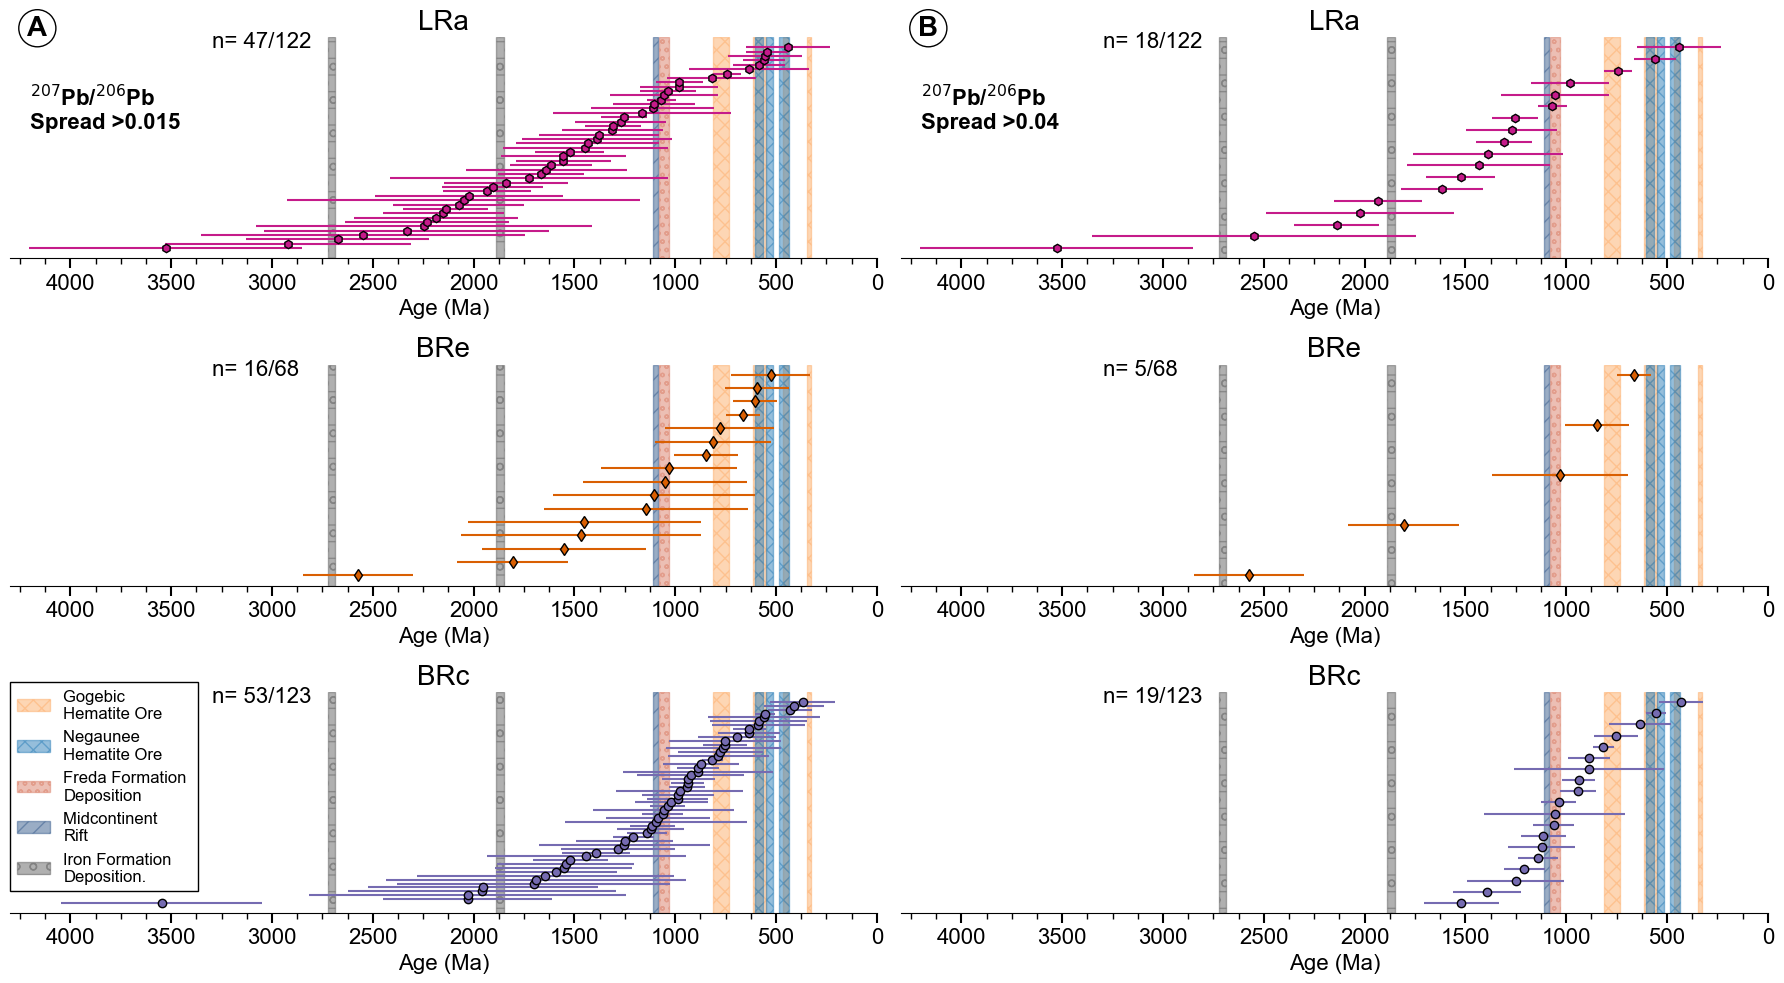

In [34]:
fig_compare = create_comparison_figure(all_data)


#fig_compare.savefig('../figures/paper_fig/age_rank_comp.pdf',dpi=300,bbox_inches='tight')

# Texture Plots 

In this section we make plots splitting out the data by the associated textures 

These textures are: 
- IF: Iron Formation
- MH: Micaceous Hematite 
- M: Massive Hematite 
- EH: Exsolved Hematite 
- FH: Fiborous 

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX',
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt

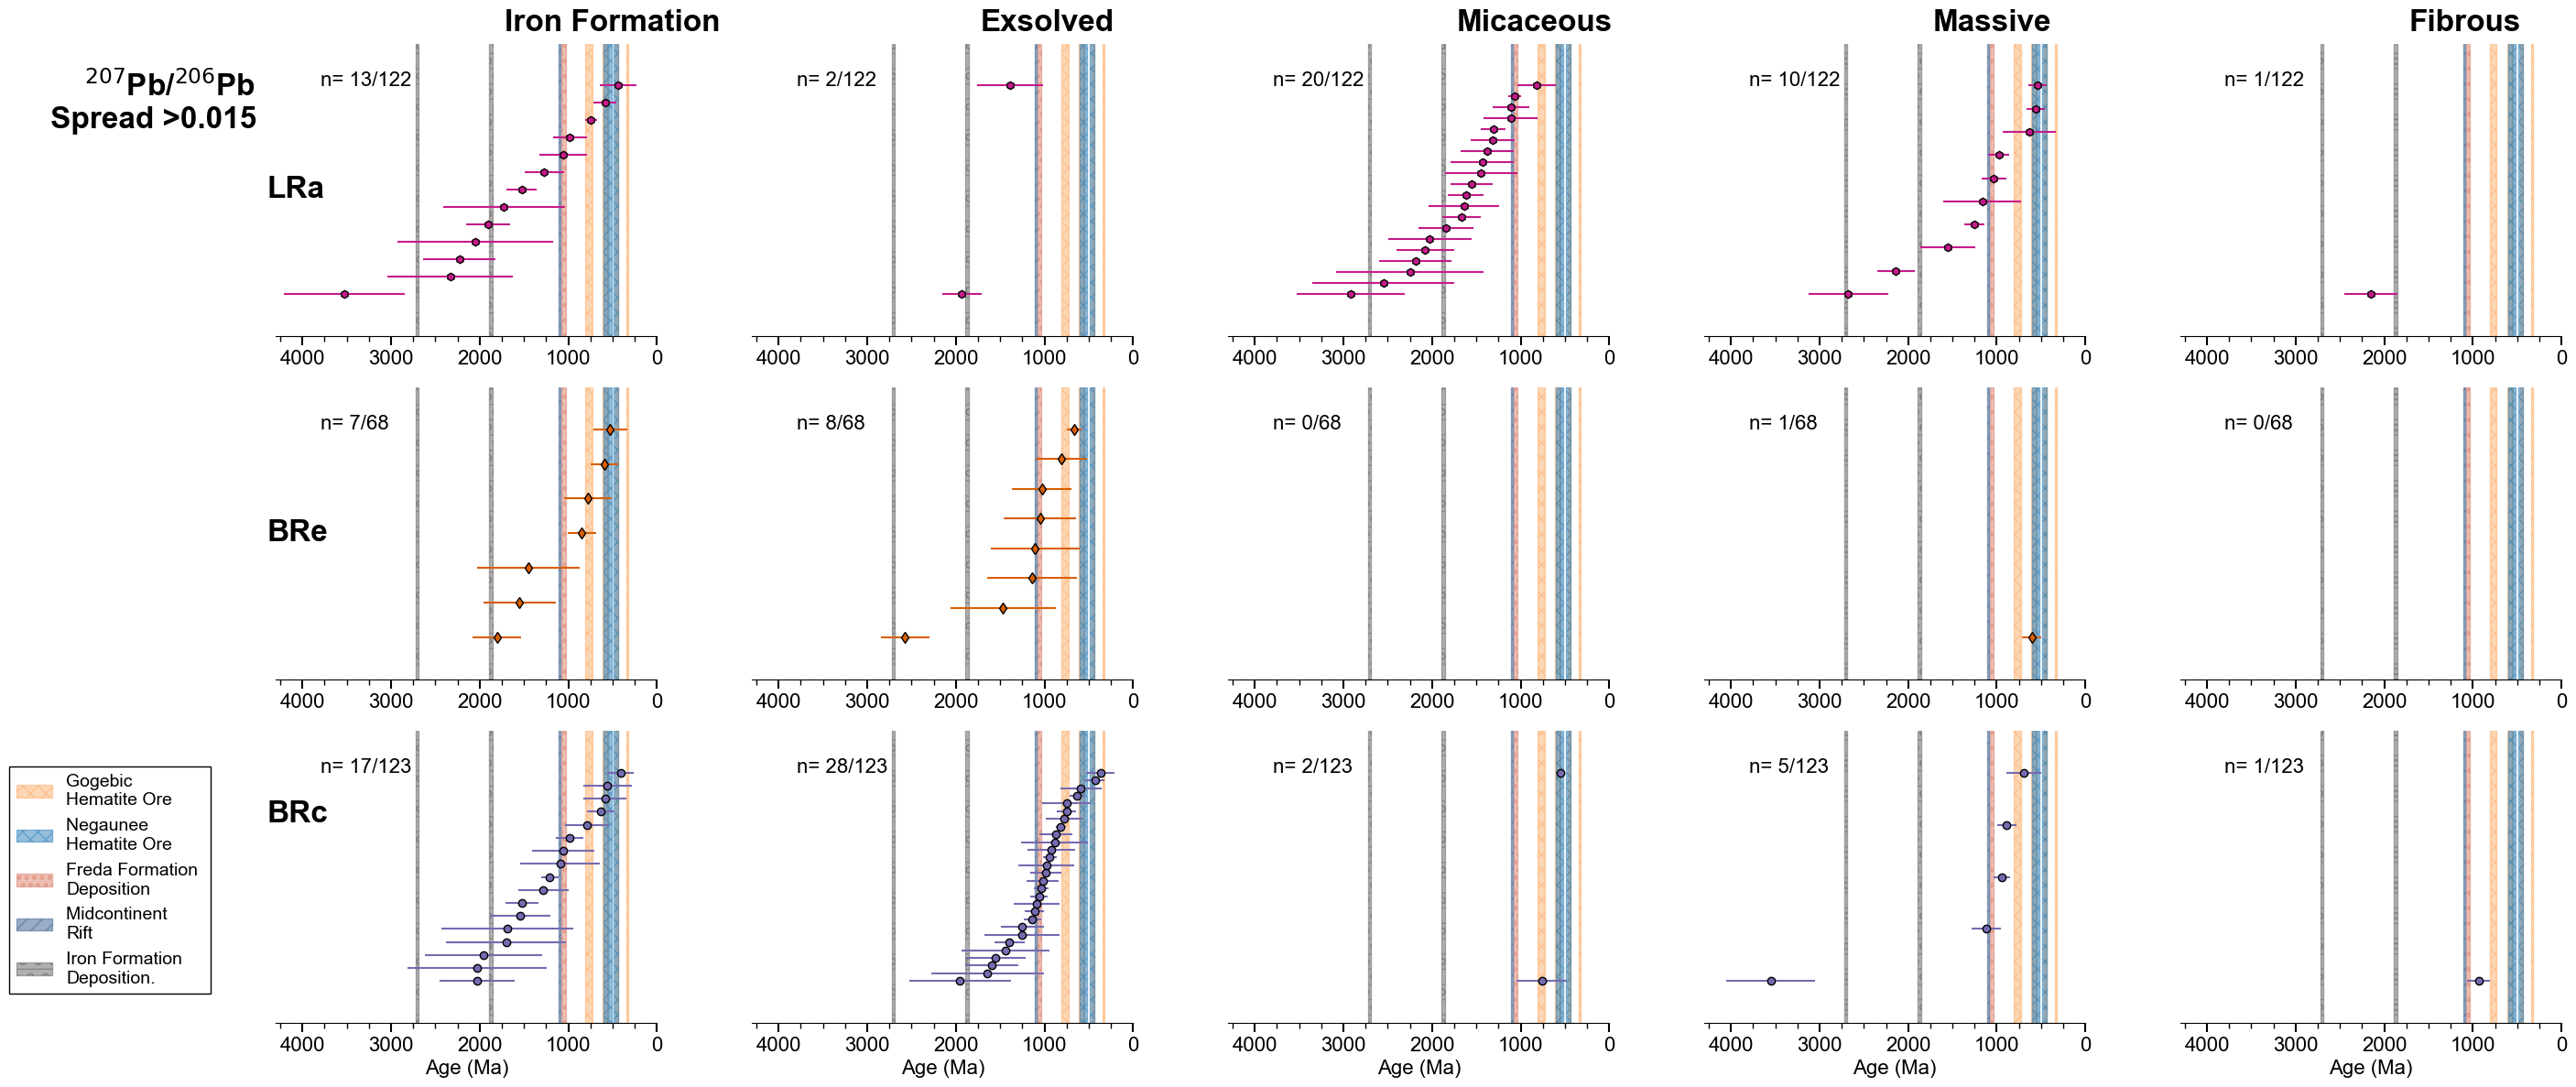

In [35]:
lo_text=plot_texture_grid(all_txt,thresholds=thrsh,colors=clr_dict,markers=mrk_dict,total_counts=tot_grains,filter_mode='low')
lo_text.savefig('../figures/si_fig/low_texture_ages.pdf',dpi=300,bbox_inches='tight')

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX',
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt

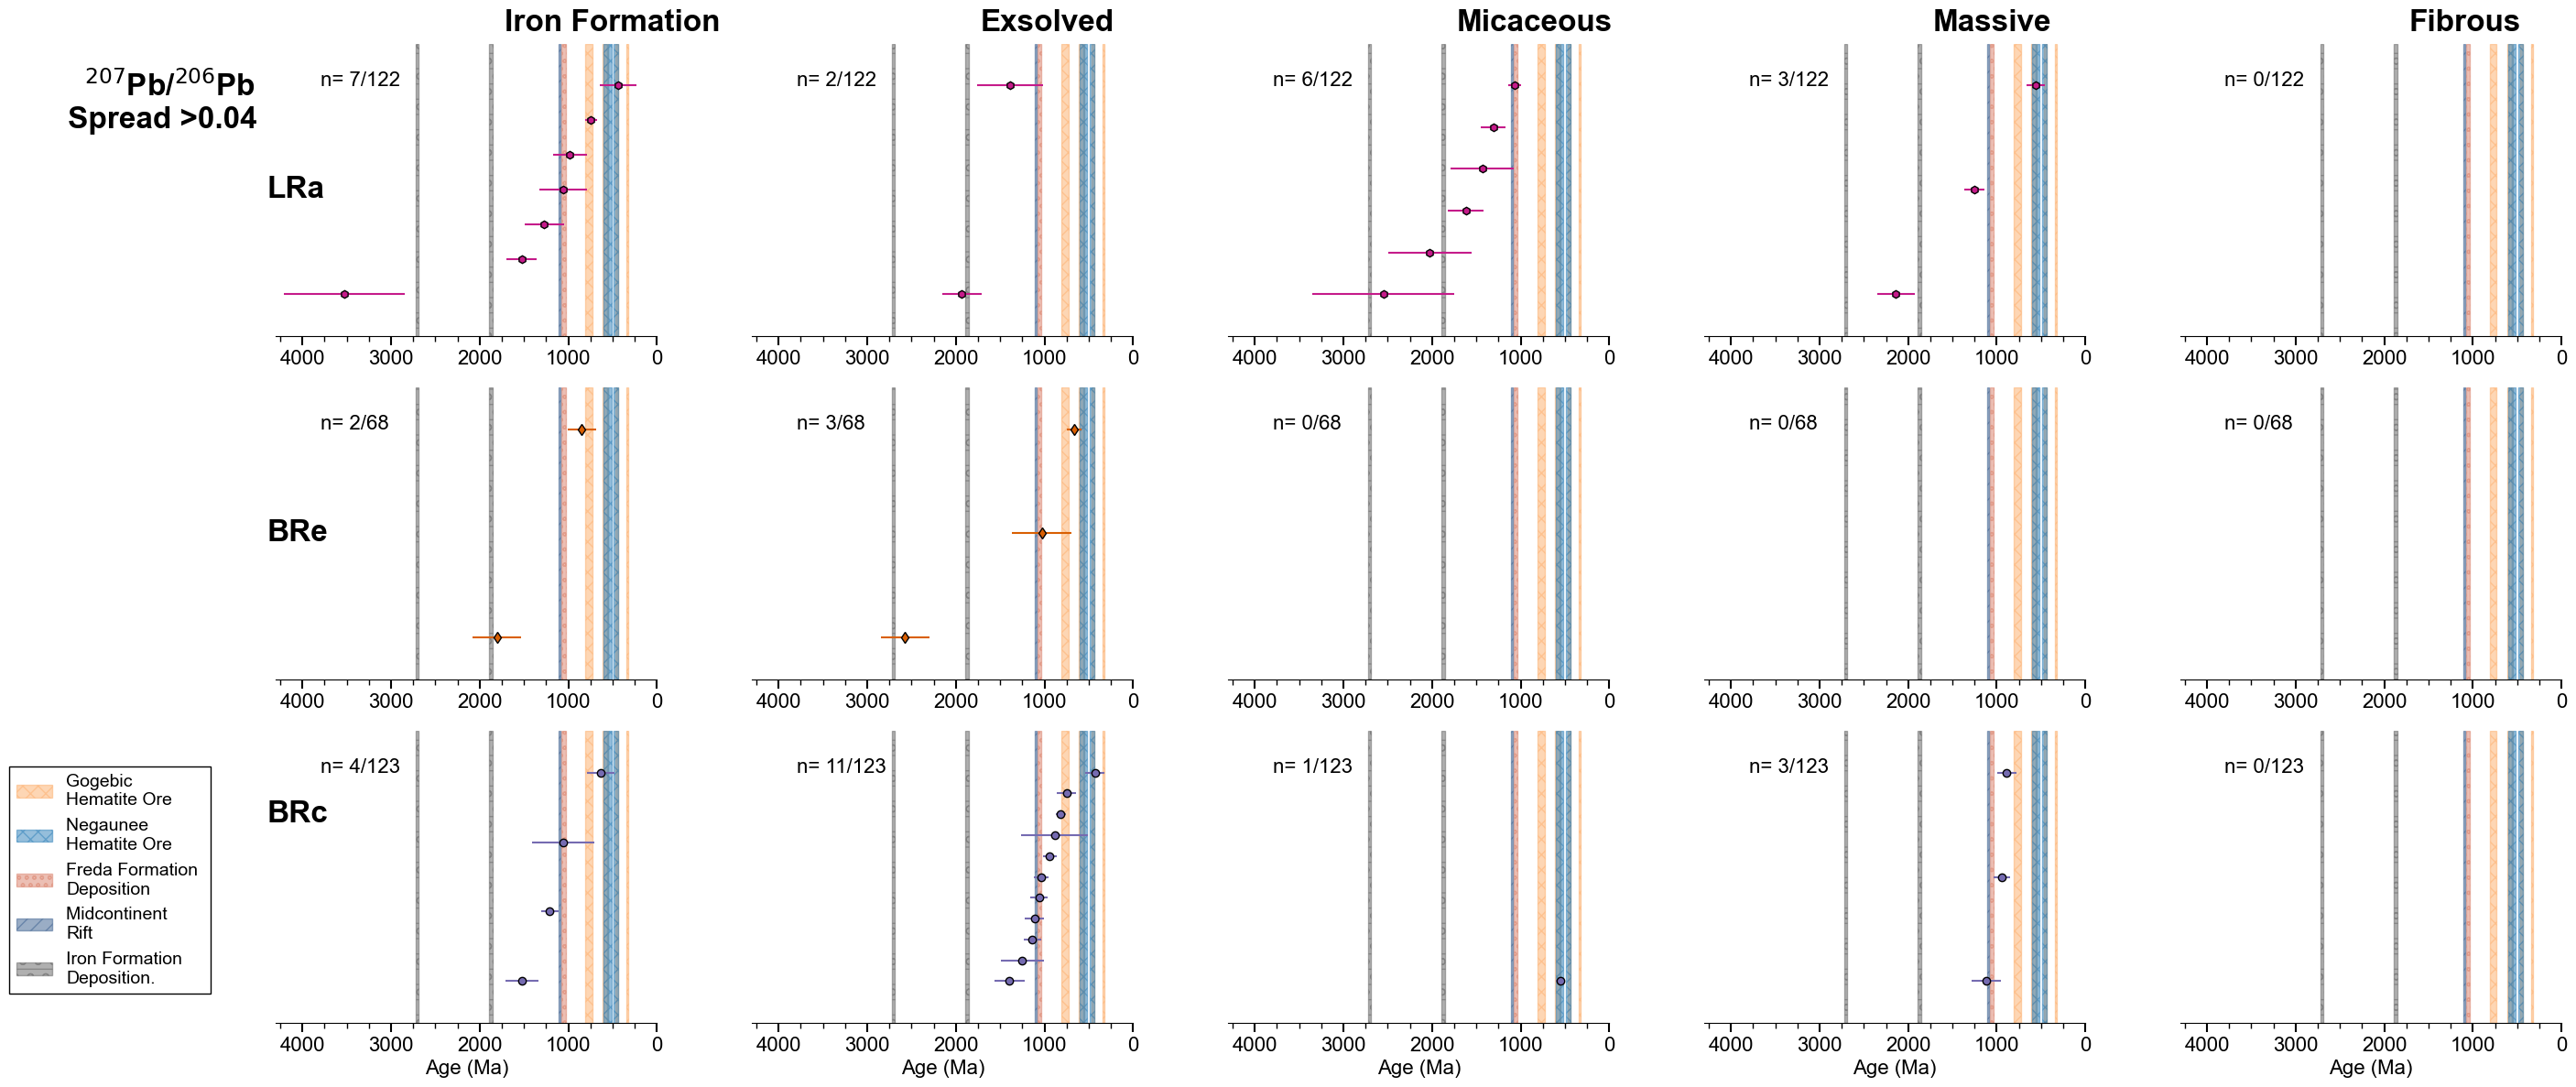

In [36]:
hi_text=plot_texture_grid(all_txt,thresholds=thrsh,colors=clr_dict,markers=mrk_dict,total_counts=tot_grains,filter_mode='high')
hi_text.savefig('../figures/si_fig/hi_texture_ages.pdf',dpi=300,bbox_inches='tight')

# Age vs Composition Plots 

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX',
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt

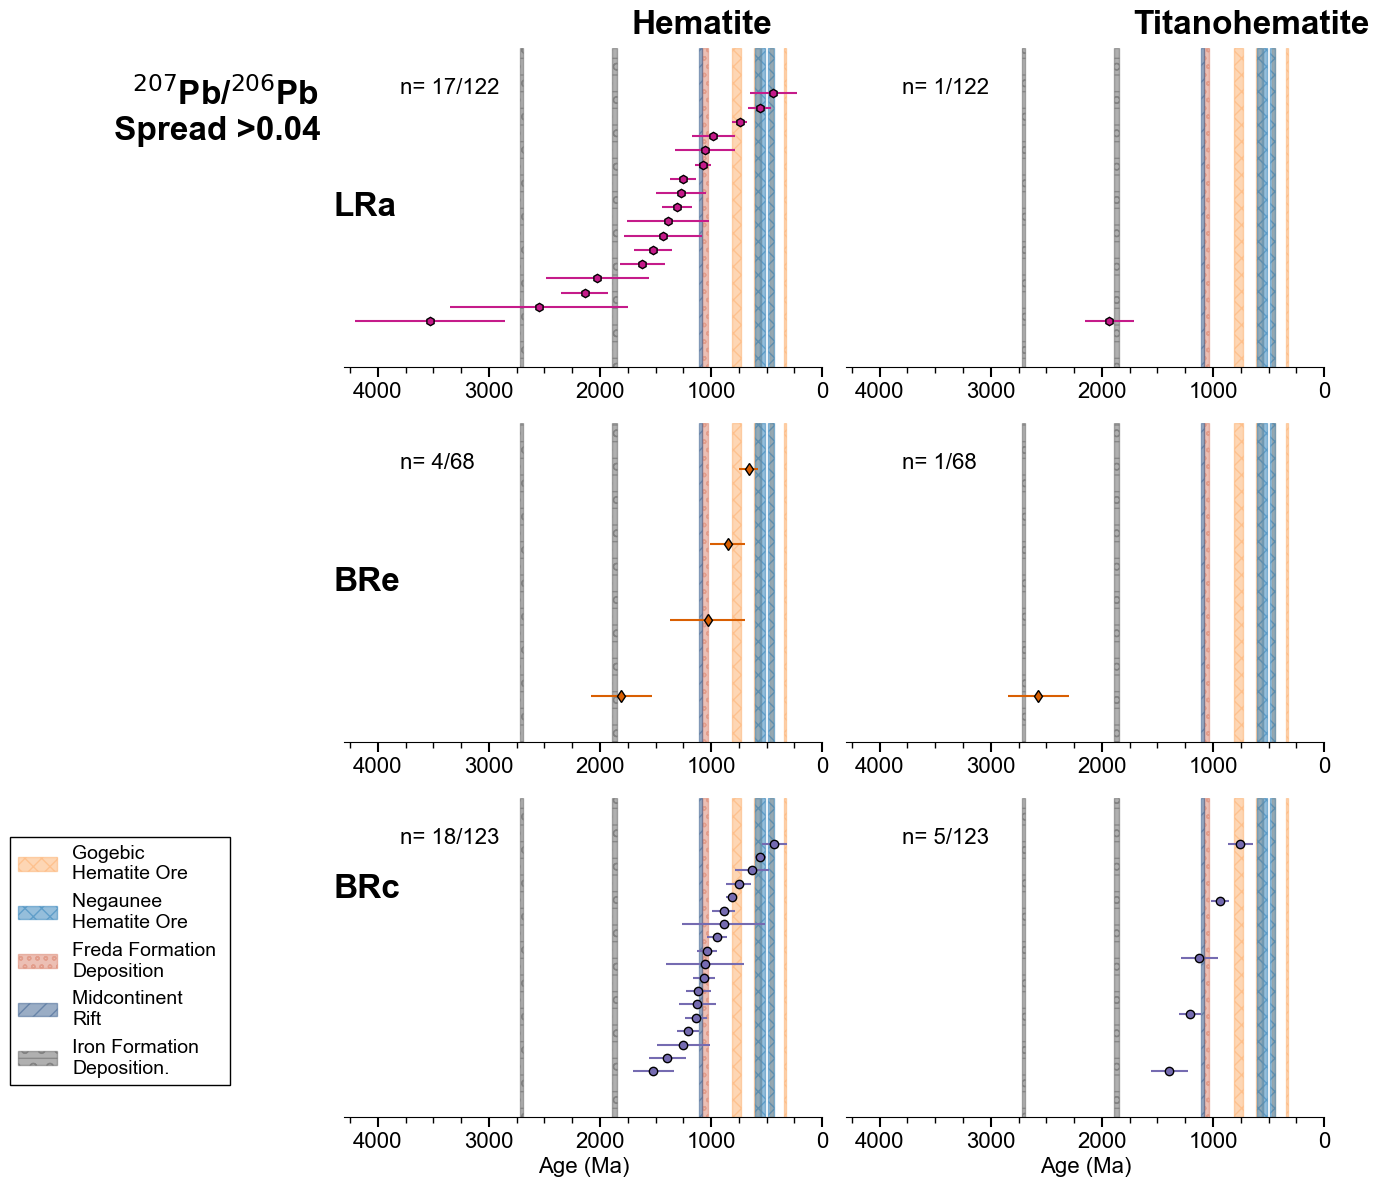

In [37]:
fig=comp_plot(all_hem=all_hem,all_ti=all_ti,thresholds=thrsh,colors=clr_dict,markers=mrk_dict,total_counts=tot_grains,filter_mode='high')

fig.savefig('../figures/si_fig/comp_comp_hi.pdf',dpi=300,bbox_inches='tight')

/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_01[0], ne_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_01[0], he_01[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(ne_02[0], ne_02[1], color=frly_color, hatch='XX',
/var/folders/cj/xt_j0gq17bz7v5r3hl3h6fxm0000gn/T/ipykernel_89147/3350462379.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(he_02[0], he_02[1], color=frly_color, hatch='XX', **kw)
/var/folders/cj/xt

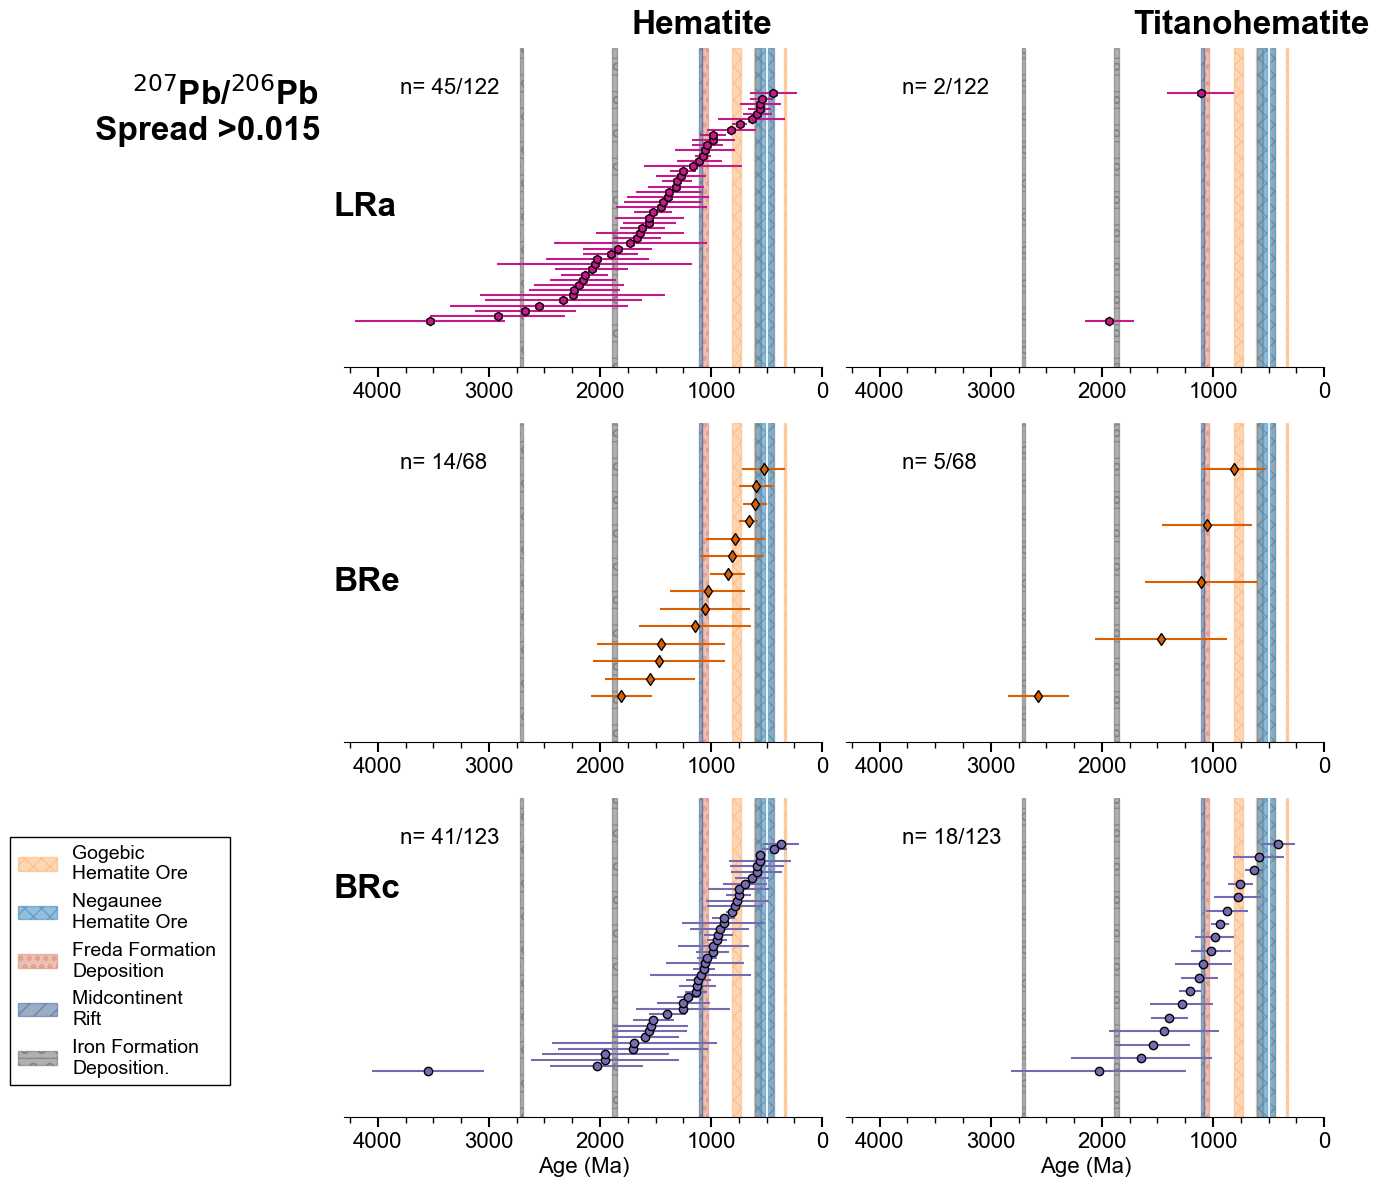

In [38]:
fig=comp_plot(all_hem=all_hem,all_ti=all_ti,thresholds=thrsh,colors=clr_dict,markers=mrk_dict,total_counts=tot_grains,filter_mode='low')

fig.savefig('../figures/si_fig/comp_comp_low.pdf',dpi=300,bbox_inches='tight')

### Ti and Fe vs Age 

Here we consider the relationship between the Ti and Fe atomic % from the EDS analyses vs the resultant isochron ages

#### Data import and concatenation

In [42]:
eds_data=pd.read_csv('../data/eds/atomic_tables/full_eds_table.csv')
fe_data=eds_data[['Grain','Fe','Fe_se']]


Combine all ages based upon filtering threshold 

In [44]:
all_hi_ages=pd.concat([lra_hi,bre_hi,brc_hi],ignore_index=True)
all_lo_ages=pd.concat([lra_lo,bre_lo,brc_lo],ignore_index=True)

In [45]:
fe_data_hi=fe_data[fe_data['Grain'].isin(all_hi_ages['sample'])].copy()
fe_data_lo=fe_data[fe_data['Grain'].isin(all_lo_ages['sample'])].copy()


fe_hi_filter=all_hi_ages[all_hi_ages['sample'].isin(fe_data_hi['Grain'])].copy()
fe_hi_filter=fe_hi_filter.rename(columns={'sample':'Grain'})
fe_hi=pd.merge(fe_hi_filter,fe_data_hi,on='Grain')

fe_lo_filter=all_lo_ages[all_lo_ages['sample'].isin(fe_data_lo['Grain'])].copy()
fe_lo_filter=fe_lo_filter.rename(columns={'sample':'Grain'})

fe_lo=pd.merge(fe_lo_filter,fe_data_lo,on='Grain')

In [46]:
ti_filter=eds_data[['Grain','Ti','Ti_se']]


ti_hi_filter=ti_filter[ti_filter['Grain'].isin(all_hi_ages['sample'])].copy()
ti_hi_filter=all_hi_ages[all_hi_ages['sample'].isin(ti_hi_filter['Grain'])].copy()
ti_hi_filter=ti_hi_filter.rename(columns={'sample':'Grain'})

ti_hi=pd.merge(ti_hi_filter,ti_filter,on='Grain')

ti_lo_filter=ti_filter[ti_filter['Grain'].isin(all_lo_ages['sample'])].copy()
ti_lo_filter=all_lo_ages[all_lo_ages['sample'].isin(ti_lo_filter['Grain'])].copy()
ti_lo_filter=ti_lo_filter.rename(columns={'sample':'Grain'})

ti_lo=pd.merge(ti_lo_filter,ti_filter,on='Grain')

Font dictionaries

In [47]:
title_font = {
    'family': 'Arial',
    'fontsize': 16,
    'fontweight': 'bold',
    'color': 'black'
}

axis_font = {
    'family': 'Arial',
    'fontsize': 14,
    'color': 'black'
}


fe_marker_style = {
    'marker': 'h',       # 'h' is the hexagon marker
    'c': 'red',          # Face color
    'edgecolors': 'k',   # Black outline
    's': 60,             # Size
    'alpha': 0.7,        # Transparency
    'linewidth': 0.5     # Edge width
}


ti_marker_style = {
    'marker': 'p',       # 'p' is the pentagon marker
    'c': 'grey',         # Face color
    'edgecolors': 'k',   # Black outline
    's': 60,             # Size
    'alpha': 0.7,        # Transparency
    'linewidth': 0.5     # Edge width
}

line_style = {
    'color': 'black',
    'linestyle': '-',
    'linewidth': 2
}

#### Compositional plotting

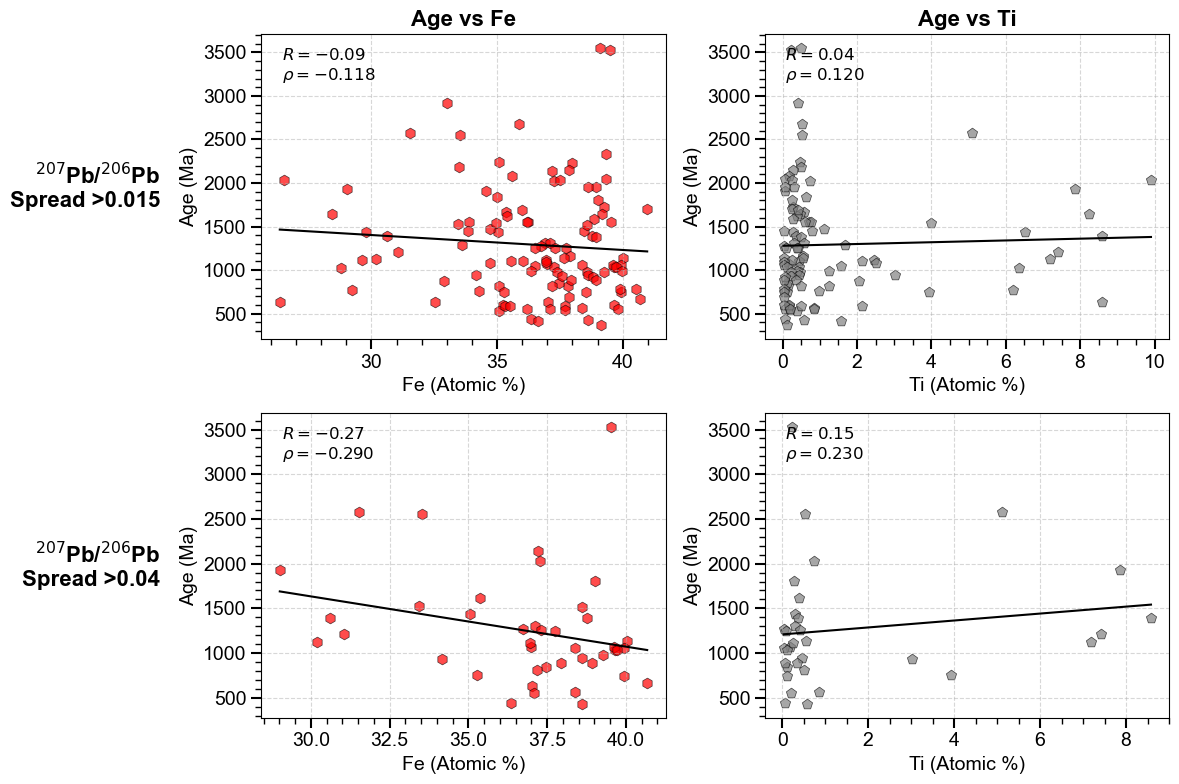

In [48]:
fig = plot_chem_grid(
    fe_low=fe_lo,   
    fe_high=fe_hi, 
    ti_low=ti_lo, 
    ti_high=ti_hi,
    thresholds=thrsh,
    fe_marker_style=fe_marker_style,
    ti_marker_style=ti_marker_style,
    title_font=title_font,
    axis_font=axis_font,figsize=(12,8)
)

fig.savefig('../figures/si_fig/cross_plots.pdf',dpi=300,bbox_inches='tight')